<a href="https://colab.research.google.com/github/jacqueline-lopez-data/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:

# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:

# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())
print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

# Diagnóstico de valores nulos
**Dataset users**  
 - city: 11.7% de valores nulos.
  Acción recomendada: investigar e imputar si es posible (por ejemplo con información adicional del usuario o categoría "Desconocida"), ya que la ciudad puede ser importante para segmentación y el porcentaje es moderado.

 - churn_date: 88.3% de valores nulos.
   Acción recomendada: no imputar ni eliminar la columna.
   Los nulos probablemente significan que el cliente sigue activo, por lo que el valor faltante tiene significado analítico.



**Dataset usage**
 - date: 0.1% de valores nulos.
   Acción recomendada: eliminar esos registros o revisar manualmente, ya que la proporción es muy baja y no afectará el análisis.

 - duration: 55.2% de valores nulos.
   Acción recomendada: investigar relación con la columna "type". Es probable que los nulos correspondan a registros de mensajes, donde no existe duración.

 - length: 44.7% de valores nulos.
   Acción recomendada: investigar relación con la columna "type". Es probable que los nulos correspondan a llamadas, donde no existe longitud de mensaje.

# Conclusión general:
- No todos los valores nulos representan errores de calidad.
- Algunas ausencias parecen estructurales y dependen del tipo de interacción (llamada o mensaje), por lo que deben analizarse antes de imputar o eliminar datos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



**La columna user_id:**
 - Contiene identificadores únicos de usuarios.
 - No presenta valores faltantes y el rango va de 10000 a 13999, por lo que parece consistente y
útil como identificador, aunque no aporta información estadística para el análisis.

**La columna age:**
- Presenta valores atípicos importantes.
- La edad mínima es -999, lo cual es imposible y probablemente representa un error de captura o un valor codificado incorrectamente.
- Además, la desviación estándar es muy alta (123.23), influenciada por estos valores erróneos.
- La mayoría de las edades parecen concentrarse entre 32 y 63 años.
- Acción recomendada: investigar y corregir/eliminar los registros con edades inválidas antes del análisis.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length,is_text,is_call
count,40000.00000,40000.000000,17924.000000,22104.000000,40000.000000,40000.000000
mean,20000.50000,12002.405975,5.202237,52.127398,0.552300,0.447700
std,11547.14972,1157.279564,6.842701,56.611183,0.497263,0.497263
min,1.00000,10000.000000,0.000000,0.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000,0.000000,0.000000
50%,20000.50000,12013.000000,3.500000,50.000000,1.000000,0.000000
75%,30000.25000,13005.000000,6.990000,64.000000,1.000000,1.000000
max,40000.00000,13999.000000,120.000000,1490.000000,1.000000,1.000000


**Las columnas `id` y `user_id`:**
-   Funcionan como identificadores de registros y usuarios.
-   No presentan valores faltantes y sus rangos son consistentes, por lo que parecen correctas para relacionar y rastrear información.

**La columna `duration`:**
-   Representa la duración de llamadas.
-   Tiene muchos valores nulos porque probablemente no aplica a registros de mensajes.
-   La duración mínima es 0 minutos, lo que podría indicar llamadas fallidas o muy cortas.
-   El valor máximo es 120 minutos, lo cual podría considerarse un posible valor atípico y merece revisión.

**La columna `length`:**
-   Representa la longitud de mensajes.
-   Tiene muchos valores nulos porque probablemente no aplica a registros de llamadas.
-   La mayoría de los mensajes tienen una longitud moderada (mediana de 50 caracteres), aunque existe un valor máximo de 1490 caracteres, que podría ser un mensaje excepcionalmente largo o un posible outlier.

**En general:**
-   Los valores nulos en `duration` y `length` parecen estructurales, ya que dependen del tipo de interacción (`call` o `message`) y no necesariamente representan errores de calidad.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts())


Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


**La columna `city`:**
-   Contiene varias ciudades de México y Colombia.
-   Se observa la presencia del valor "?", que probablemente representa datos faltantes o mal capturados. Este valor debe reemplazarse por NaN para tratarlo correctamente en el análisis.
-   Bogotá y CDMX son las ciudades con mayor cantidad de usuarios registrados.

**La columna `plan`:**
-   Solo contiene dos categorías: "Basico" y "Premium".
-   No presenta valores extraños ni inconsistencias aparentes.
-   El plan "Basico" es el más utilizado, con una mayor proporción de usuarios respecto a "Premium".

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

**La columna `type`:**
-   Contiene dos categorías: "text" y "call", que representan mensajes y llamadas respectivamente.
-   No se observan valores inconsistentes o desconocidos.
-   La cantidad de registros de mensajes ("text") es ligeramente mayor que la de llamadas ("call").
-   Esta columna es clave para interpretar correctamente los valores nulos en `duration` y `length`, ya que cada tipo de interacción utiliza diferentes variables.

✍️ **Comentario:**

## Valores inválidos o sentinels ##

- En la columna `age` se encontró el valor `-999`, el cual es inválido para una edad y probablemente representa un valor sentinel o un error de captura.
  **Acción recomendada:** reemplazar esos valores por `NaN` y posteriormente decidir si imputarlos o eliminar esos registros.

- En la columna `city` se encontró el valor `"?"`, que probablemente representa información desconocida o faltante.
  **Acción recomendada:** reemplazar `"?"` por `NaN` para tratarlo correctamente como dato faltante.

- En las columnas `duration` y `length` existen muchos valores nulos, pero no parecen errores.
  Los nulos dependen del tipo de interacción (`call` o `text`), por lo que son valores estructurales y no deben imputarse automáticamente.
  **Acción recomendada:** mantener los nulos y analizarlos según la columna `type`.

- En la columna `duration` existen valores mínimos de `0`, que podrían representar llamadas fallidas o extremadamente cortas.
  **Acción recomendada:** investigar si estos registros deben mantenerse o excluirse según el objetivo del análisis.

- En la columna `length` se observa un valor máximo de `1490`, considerablemente mayor al resto.
  **Acción recomendada:** revisar si corresponde a un mensaje válido o si se trata de un posible outlier.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, se observan registros correspondientes a los años 2022, 2023, 2024 y 2026.
La presencia de fechas en 2026 podría ser inconsistente dependiendo del periodo real del dataset, por lo que conviene verificar si se trata de errores de captura o fechas futuras válidas.
**Acción recomendada:** revisar los registros de 2026 para confirmar su validez antes del análisis.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, los registros corresponden únicamente al año 2024, además de algunos valores nulos previamente identificados.

Esto indica que el dataset de uso está concentrado en un solo periodo temporal, lo cual facilita el análisis comparativo sin necesidad de ajustar por múltiples años.

**Acción recomendada:** mantener el análisis enfocado en 2024 y revisar o eliminar los pocos registros con fechas nulas, ya que representan una proporción mínima del dataset.

✍️ **Comentario:**

## Fechas fuera de rango

- En la columna `reg_date` aparecen registros de los años 2022, 2023, 2024 y 2026.
  Los años 2022–2024 parecen coherentes, pero 2026 podría representar una fecha futura respecto al periodo principal del análisis, por lo que podría tratarse de un error de captura o una inconsistencia.

  **Acción recomendada:** revisar específicamente los registros de 2026 para confirmar si son válidos. Si se detecta que son errores, corregirlos o excluirlos del análisis.

- En la columna `date` del dataset `usage`, todos los registros válidos pertenecen al año 2024.
  No se observan años imposibles ni fuera de rango, únicamente algunos valores nulos ya identificados anteriormente.

  **Acción recomendada:** mantener el análisis centrado en 2024 y eliminar o revisar los registros con fechas faltantes debido a su baja proporción.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores nulos:", users['city'].isna().sum())
print("¿Todavía hay '?' en city?:", '?' in users['city'].values)

Valores nulos: 565
¿Todavía hay '?' en city?: False


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Fechas nulas después de la limpieza:", users['reg_date'].isna().sum())
print("Años únicos restantes:", sorted(users['reg_date'].dt.year.dropna().unique()))

Fechas nulas después de la limpieza: 40
Años únicos restantes: [2022.0, 2023.0, 2024.0]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print("Análisis de nulos en duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))
print("\nProporción de nulos en duration por tipo:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

Análisis de nulos en duration por tipo:
type
call        0
text    22076
Name: duration, dtype: int64

Proporción de nulos en duration por tipo:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("Análisis de nulos en length por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))
print("\nProporción de nulos en length por tipo:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

Análisis de nulos en length por tipo:
type
call    17896
text        0
Name: length, dtype: int64

Proporción de nulos en length por tipo:
type
call    0.99933
text    0.00000
Name: length, dtype: float64



Los valores nulos en las columnas duration y length presentan un patrón claramente asociado a la variable type, por lo que pueden clasificarse como **MAR (Missing At Random)**

En la columna duration, los valores nulos aparecen casi exclusivamente en los registros de tipo text (99.93%), mientras que los registros de tipo call no presentan valores faltantes. Esto indica que la duración solo aplica a llamadas telefónicas y no a mensajes de texto.

Por otro lado, en la columna length, ocurre el comportamiento contrario: los valores nulos se concentran en los registros de tipo call (99.93%), mientras que los registros de tipo text contienen información completa. Esto se debe a que la longitud del mensaje únicamente tiene sentido para mensajes de texto y no para llamadas.

Debido a que los valores faltantes dependen directamente del tipo de interacción y representan ausencia lógica de información, se decidió mantener los nulos sin imputación. Reemplazarlos por valores arbitrarios podría introducir sesgos y afectar negativamente el análisis posterior.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',           # total de mensajes
    'is_call': 'sum',           # total de llamadas
    'duration': 'sum'           # total de minutos de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print("Distribución porcentual por tipo de plan:")
print(user_profile['plan'].value_counts(normalize=True) * 100)
print("\nConteo absoluto por tipo de plan:")
print(user_profile['plan'].value_counts())

Distribución porcentual por tipo de plan:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64

Conteo absoluto por tipo de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

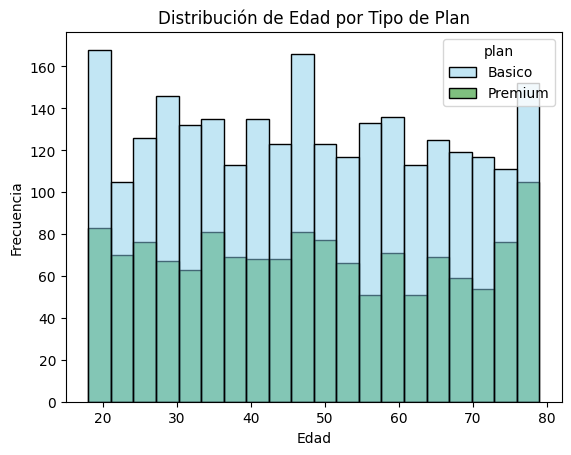

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=20)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La distribución de edades entre los planes Básico y Premium es bastante similar, por lo que no se observa un patrón claro que indique que un grupo de edad prefiera un plan específico. La mayor concentración de usuarios se encuentra entre los 25 y 60 años aproximadamente.

- El plan Básico presenta una mayor frecuencia total de usuarios en casi todos los rangos de edad, lo cual podría deberse a que tiene más clientes registrados en general.

- La distribución de la variable age puede considerarse relativamente uniforme o cercana a simétrica, ya que las edades se encuentran distribuidas de manera bastante equilibrada a lo largo de los intervalos y no se aprecia un sesgo marcado hacia edades jóvenes o mayores.

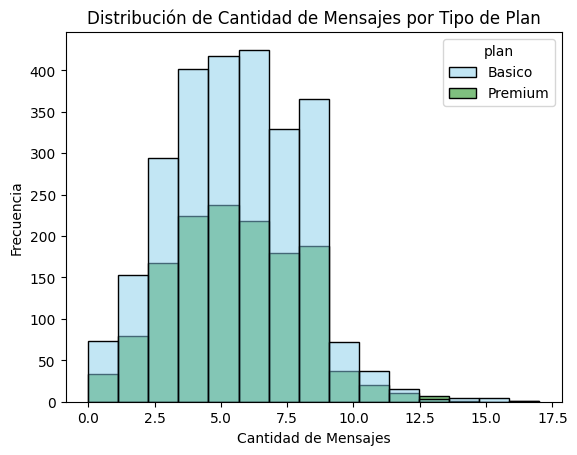

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La cantidad de mensajes enviados presenta una distribución similar entre los planes Básico y Premium. La mayoría de los usuarios envía entre 3 y 8 mensajes, concentrándose especialmente alrededor de 5 a 7 mensajes.

- No se observa una diferencia significativa entre ambos planes en cuanto al comportamiento de envío de mensajes, aunque el plan Básico tiene una frecuencia ligeramente mayor debido a la mayor cantidad de usuarios.

- La distribución tiene un ligero sesgo a la derecha, ya que existen pocos usuarios que envían cantidades altas de mensajes (más de 10), mientras que la mayoría se concentra en valores medios y bajos.

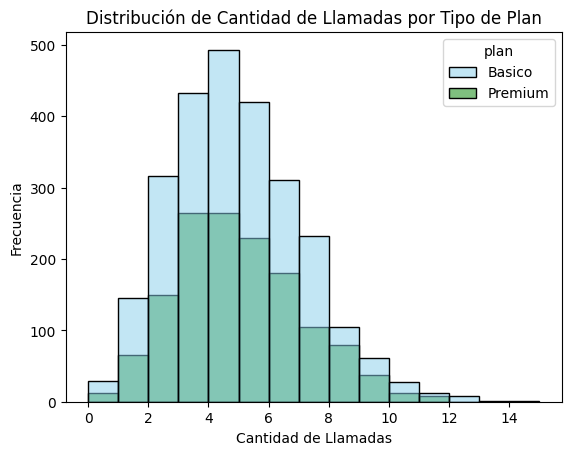

In [ ]:

# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- La distribución de la cantidad de llamadas es muy similar entre los usuarios de los planes Básico y Premium. La mayor concentración de usuarios realiza entre 3 y 7 llamadas, siendo alrededor de 4 a 5 llamadas el rango más frecuente.

- No se observa una diferencia marcada en el comportamiento de llamadas entre ambos planes, aunque el plan Básico presenta una frecuencia mayor debido a que cuenta con más usuarios en la muestra.

- La distribución presenta un ligero sesgo a la derecha, ya que existen pocos usuarios que realizan una cantidad alta de llamadas (más de 10), mientras que la mayoría se concentra en valores medios. Esto indica que los casos de usuarios con muchas llamadas son menos frecuentes.

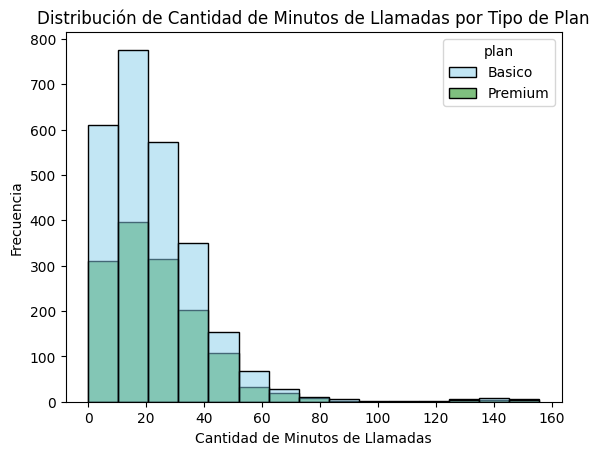

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=15)
plt.title('Distribución de Cantidad de Minutos de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Minutos de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La variable cant_minutos_llamada presenta una distribución sesgada a la derecha, indicando que la mayoría de los usuarios realiza una cantidad relativamente baja de minutos de llamada, mientras que pocos usuarios concentran consumos elevados. Ambos planes muestran patrones similares; sin embargo, el plan Básico registra una mayor frecuencia de usuarios en casi todos los rangos de minutos. Asimismo, se identifican posibles valores atípicos en ambos planes, especialmente por encima de los 100 minutos de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

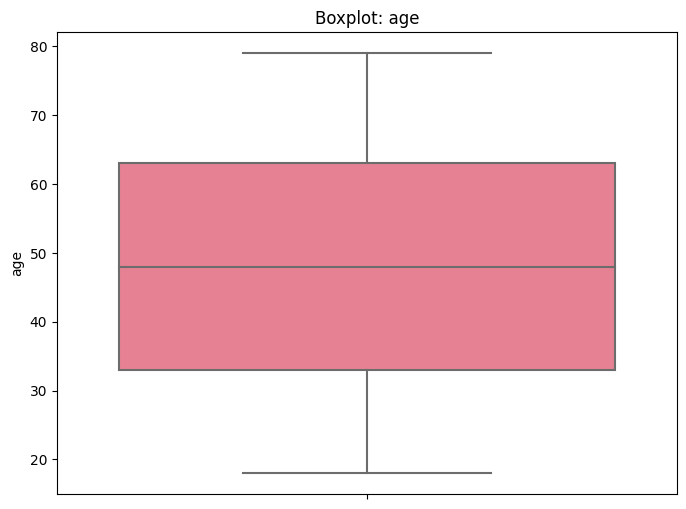

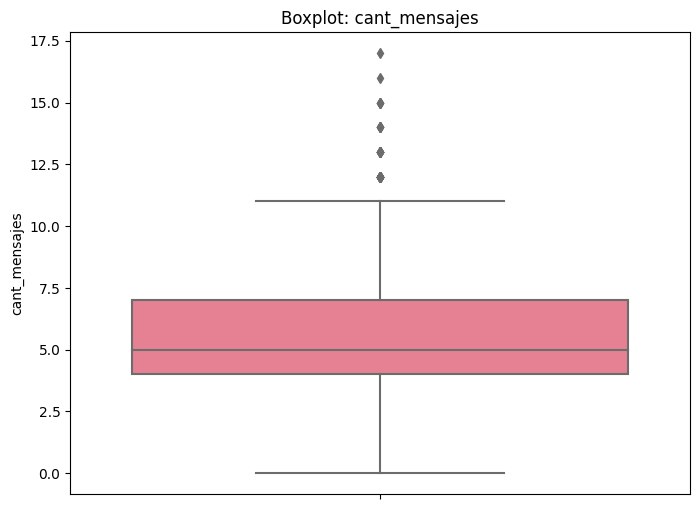

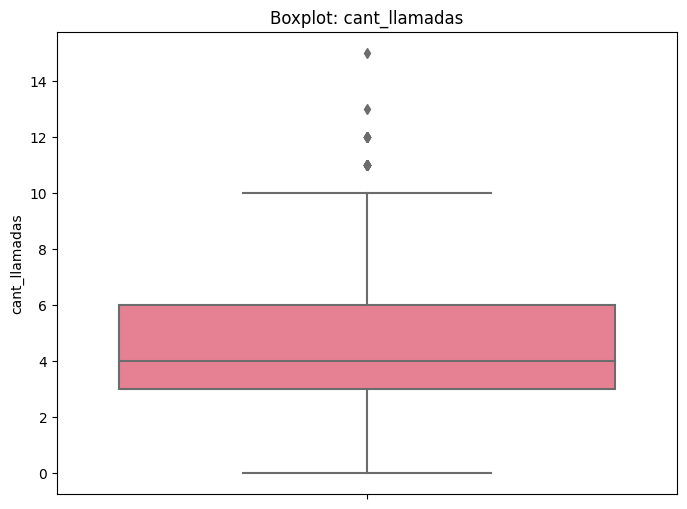

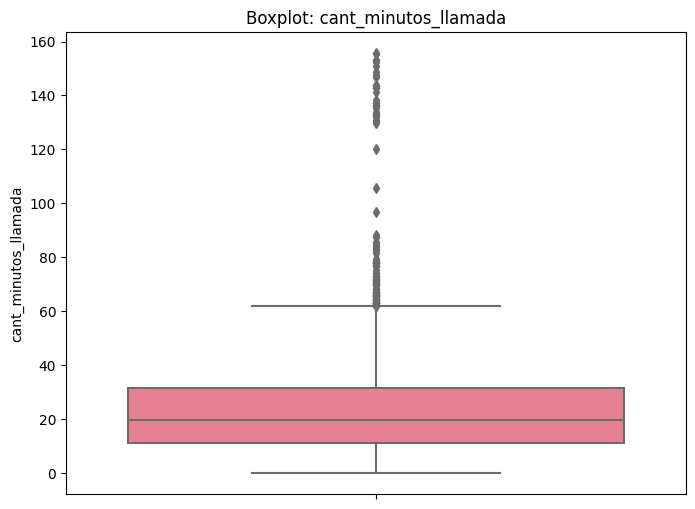

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights:
- age:
La variable age no presenta outliers visibles en el boxplot. Las edades de los usuarios se encuentran dentro de un rango esperado y la distribución parece relativamente estable, sin valores extremos que puedan afectar el análisis.
- cant_mensajes:
La variable cant_mensajes sí presenta outliers superiores. Se observan algunos usuarios que envían una cantidad considerablemente mayor de mensajes en comparación con la mayoría de la población. Estos valores extremos podrían representar usuarios con un uso intensivo del servicio, aunque no necesariamente errores en los datos.
- cant_llamadas:
La variable cant_llamadas presenta algunos outliers superiores. Existen usuarios que realizan muchas más llamadas que el resto, lo que genera una distribución sesgada hacia la derecha. Sin embargo, la mayoría de los usuarios se concentra en rangos bajos y moderados de llamadas.
- cant_minutos_llamada:
La variable cant_minutos_llamada presenta una cantidad importante de outliers superiores. Algunos usuarios acumulan una cantidad muy elevada de minutos de llamada en comparación con el comportamiento general. Esto indica la presencia de clientes con un consumo intensivo del servicio y una distribución fuertemente sesgada a la derecha.



Aunque se identificaron outliers en varias variables de uso, estos podrían representar comportamientos reales de clientes con alto consumo y no necesariamente errores de captura. Por esta razón, se recomienda mantenerlos en el análisis, aunque podrían revisarse por separado en estudios posteriores para entender mejor los patrones de consumo extremo.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"\n{col}:")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Valor máximo real: {user_profile[col].max():.2f}")


cant_mensajes:
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50
Valor máximo real: 17.00

cant_llamadas:
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50
Valor máximo real: 15.00

cant_minutos_llamada:
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86
Valor máximo real: 155.69


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes:
Aunque existen outliers superiores en la variable cant_mensajes, se decidió mantenerlos porque el valor máximo observado (17 mensajes) no se encuentra extremadamente alejado del límite superior calculado con IQR (11.5). Además, estos valores pueden representar usuarios con un uso más frecuente del servicio y no necesariamente errores en los datos.
- cant_llamadas:
Se decidió conservar los outliers de cant_llamadas, ya que el valor máximo real (15 llamadas) no es excesivamente distante del límite superior calculado (10.5). Estos casos podrían corresponder a clientes con mayor actividad telefónica, por lo que forman parte del comportamiento real de algunos usuarios.
- cant_minutos_llamada:
La variable cant_minutos_llamada presenta outliers más notorios, debido a que el valor máximo real (155.69 minutos) supera considerablemente el límite superior calculado (61.86). Sin embargo, se decidió mantener estos registros porque podrían representar clientes con consumo intensivo del servicio y resultan valiosos para identificar patrones de uso extremo dentro de la empresa de telecomunicaciones.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'  # Valor por defecto

# Aplicar condiciones específicas
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) & (user_profile['grupo_uso'] != 'Bajo uso'), 'grupo_uso'] = 'Uso medio'

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'  # Valor por defecto

# Aplicar condiciones específicas
user_profile.loc[(user_profile['age'] < 30) , 'grupo_edad'] = 'Joven'
user_profile.loc[(user_profile['age'] < 60) & (user_profile['grupo_edad'] != 'Joven'), 'grupo_edad'] = 'Adulto'

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

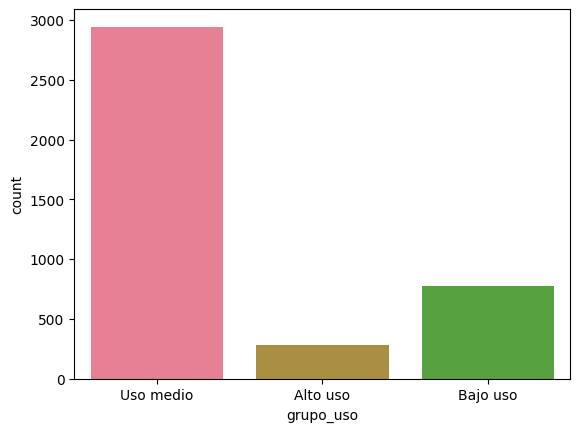

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.show()

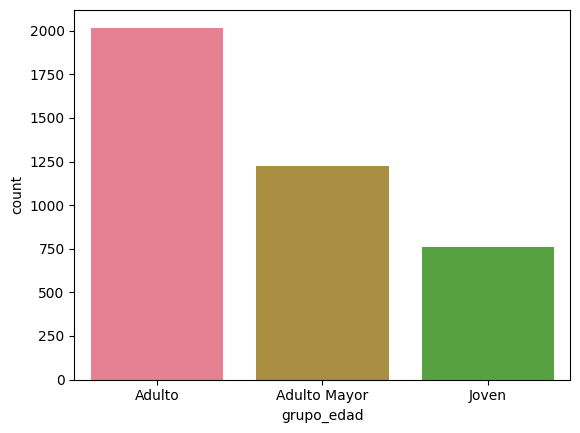

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante el análisis exploratorio se identificaron distintos problemas de calidad de datos que requerían limpieza y validación antes de realizar el análisis de negocio.

- En el dataset users, la columna city presentaba 469 valores nulos originalmente, equivalentes al 11.7% de los registros. Además, se identificaron 96 registros con el valor "?", considerado un valor inválido o sentinel, los cuales fueron reemplazados por NaN para tratarlos correctamente como datos faltantes.
- La columna churn_date contenía 3534 valores nulos (88.3%). Sin embargo, estos nulos no fueron considerados errores, ya que probablemente indican clientes activos que no han cancelado el servicio.
En el dataset usage, la columna date tenía únicamente 50 valores nulos (0.1%), por lo que se determinó que no afectarían significativamente el análisis.
- Las columnas duration y length presentaban altos porcentajes de nulos (55.2% y 44.7%, respectivamente). Tras el análisis, se concluyó que estos valores faltantes eran estructurales y dependían del tipo de interacción (call o text), por lo que se mantuvieron sin imputación.
- También se detectaron valores inválidos en la columna age, específicamente el valor -999, utilizado como sentinel. Estos registros fueron reemplazados por la mediana de edad para evitar distorsiones estadísticas.
- Finalmente, se identificaron fechas futuras en reg_date correspondientes al año 2026. Estos registros fueron considerados inconsistentes respecto al periodo de análisis y se reemplazaron por valores nulos.

🔍 **Segmentos por Edad**
Se identificaron tres grupos principales de clientes según la edad:

- Jóvenes (<30 años): representan usuarios relativamente menos frecuentes y con patrones de uso moderados.
- Adultos (30–59 años): constituyen el segmento más amplio de la base de clientes y muestran un comportamiento estable tanto en llamadas como en mensajes.
- Adultos mayores (60+ años): aunque representan un segmento menor, algunos presentan niveles elevados de consumo, especialmente en llamadas.

En general, no se observaron diferencias drásticas entre planes según la edad, ya que tanto usuarios Básico como Premium presentan distribuciones similares. Sin embargo, el plan Básico concentra una mayor cantidad total de usuarios debido a su mayor participación en la base de clientes (64.9%).


📊 **Segmentos por Nivel de Uso**
El análisis permitió clasificar a los clientes en tres segmentos principales:

- Bajo uso: usuarios con menos de 5 llamadas y menos de 5 mensajes. Representan clientes con actividad limitada y posiblemente baja dependencia del servicio.
- Uso medio: usuarios con actividad moderada tanto en llamadas como mensajes. Este grupo parece representar el comportamiento más común dentro de la empresa.
- Alto uso: usuarios con altos volúmenes de llamadas o mensajes. Este segmento concentra los consumos más elevados y representa oportunidades importantes de monetización.

Se observó que la mayoría de los usuarios se concentra en rangos moderados de llamadas, mensajes y minutos consumidos. Las distribuciones presentan sesgos a la derecha, indicando que existe un grupo reducido de clientes con consumos considerablemente mayores al promedio.

➡️ Esto sugiere que ConnectaTel cuenta con una base de clientes relativamente estable, pero con segmentos específicos de alto consumo que podrían beneficiarse de ofertas diferenciadas o planes personalizados.


📈 **Patrones de uso extremo (Outliers)**

Se identificaron outliers principalmente en las variables:

- cant_mensajes
- cant_llamadas
- cant_minutos_llamada

El caso más notable fue cant_minutos_llamada, donde algunos usuarios alcanzaron consumos de hasta 155.69 minutos, superando ampliamente el límite superior calculado mediante IQR (61.86).

A pesar de esto, se decidió mantener los outliers porque:

- No parecen errores de captura.
- Representan comportamientos reales de clientes intensivos.
- Son valiosos para comprender patrones extremos de consumo y posibles oportunidades comerciales.

Estos usuarios podrían representar clientes de alto valor o perfiles con necesidades de comunicación más intensivas.

💡 **Recomendaciones**

- Diseñar planes especializados para usuarios de alto consumo, especialmente aquellos con elevados minutos de llamada, ofreciendo beneficios adicionales o paquetes ilimitados.
- Crear estrategias de fidelización para clientes de uso medio y alto, ya que representan los segmentos con mayor potencial de ingresos recurrentes.
- Implementar campañas dirigidas por segmento etario, adaptando promociones y beneficios según las necesidades de jóvenes, adultos y adultos mayores.
- Mejorar los procesos de captura y validación de datos para evitar valores inválidos como -999, "?" o fechas futuras inconsistentes.
- Continuar monitoreando los patrones de consumo extremo para detectar oportunidades de upselling y optimización de planes comerciales.
- Analizar en futuros estudios el comportamiento de cancelación (churn) y su relación con los patrones de uso, con el fin de anticipar abandono de clientes y mejorar la retención.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`